In [3]:
# EDA Notebook for AlphaCare Insurance Solutions

# This notebook provides a comprehensive Exploratory Data Analysis (EDA)
# on the historical car insurance claim data for AlphaCare Insurance Solutions.
# The goal is to understand the dataset's structure, quality, and uncover
# initial insights into risk and premium factors.

# ---
# ## 1. Setup and Data Loading
# ---

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# ---
# Data Loading from file:
# This notebook expects the 'MachineLearningRating_v3.txt' file to be
# located in a 'data' subfolder relative to where this notebook is run.
# If the file is not found, a FileNotFoundError will be raised.
# ---

df = pd.read_csv('../../data/MachineLearningRating_v3.txt', on_bad_lines='skip',delimiter='|')
print("Data loaded successfully from './data/MachineLearningRating_v3.txt'")
#print data summary
print(f"Columns found: {list(df.columns)}")
print(f"Data loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
print("First few rows of the dataset:", df.head())



C:\Users\Fitsum\AppData\Local\Temp\ipykernel_40596\1223194262.py:36: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/MachineLearningRating_v3.txt', on_bad_lines='skip',delimiter='|')


Data loaded successfully from './data/MachineLearningRating_v3.txt'
Columns found: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']
Data loaded with 1000098 rows and 52 columns.
First few rows of the dataset:    UnderwrittenCoverID  PolicyID     T

In [ ]:
# ---
# ## 2. Data Summarization
# ---

# ### 2.1 Data Structure (dtype Review)
# We inspect the data types of each column to ensure they are correctly interpreted by pandas.
# This helps in identifying columns that might need type conversion (e.g., objects that should be numeric or datetime).
print("\n--- Data Structure Overview (df.info()) ---")
df.info()

# ### 2.2 Descriptive Statistics
# Calculate descriptive statistics for numerical features to understand their central tendency,
# dispersion, and shape. We pay special attention to variability (standard deviation, min/max).
print("\n--- Descriptive Statistics for Numerical Columns ---")
# Select numerical columns for descriptive statistics
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(df[numerical_cols].describe().T)

# Specifically addressing variability for key financial columns
print("\n--- Variability for Key Numerical Features ---")
key_numerical_features = df.select_dtypes(include=np.number).columns.tolist()
columns_to_exclude = ['UnderwrittenCoverID', 'PolicyID','mmcode','NumberOfVehiclesInFleet','PostalCode']
filtered_key_numerical_features = [col for col in key_numerical_features if col not in columns_to_exclude]
for col in filtered_key_numerical_features:
    if col in df.columns:
        print(f"\n{col}:")
        mean_val = df[col].mean()
        std_val = df[col].std()
        min_val = df[col].min()
        max_val = df[col].max()
        q75_val = df[col].quantile(0.75)
        q25_val = df[col].quantile(0.25)
        iqr_val = q75_val - q25_val

        print(f"  Mean: {mean_val:,.2f}" if not pd.isna(mean_val) else "  Mean: N/A")
        print(f"  Standard Deviation: {std_val:,.2f}" if not pd.isna(std_val) else "  Standard Deviation: N/A")
        print(f"  Min: {min_val:,.2f}" if not pd.isna(min_val) else "  Min: N/A")
        print(f"  Max: {max_val:,.2f}" if not pd.isna(max_val) else "  Max: N/A")
        print(f"  Interquartile Range (IQR): {iqr_val:,.2f}" if not pd.isna(iqr_val) else "  Interquartile Range (IQR): N/A")


# t


--- Data Structure Overview (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-n

In [10]:
# ---
# ## 3. Data Quality Assessment
# ---

# ### 3.1 Check for Missing Values
# Identify the presence and percentage of missing values in each column.
# This helps in deciding on appropriate imputation or handling strategies.
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_df)
    
    # Remove columns that are completely empty
    empty_columns = missing_df[missing_df['Missing %'] == 100].index
    df.drop(columns=empty_columns, inplace=True)
    print(f"Removed empty columns: {list(empty_columns)}")
    
    # Remove rows with any missing values
    initial_row_count = len(df)
    df.dropna(inplace=True)
    removed_rows = initial_row_count - len(df)
    print(f"Removed rows with missing values: {removed_rows}")

    print("\n--- Missing values after handling ---")
    print(df.isnull().sum().sum())
    if df.isnull().sum().sum() == 0:
        print("All missing values have been handled.")



--- Missing Values Check ---
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098      100.0
Removed empty columns: ['NumberOfVehiclesInFleet']
Removed rows with missing values: 0

--- Missing values after handling ---
0
All missing values have been handled.



--- Univariate Analysis: Histograms for Numerical Columns ---


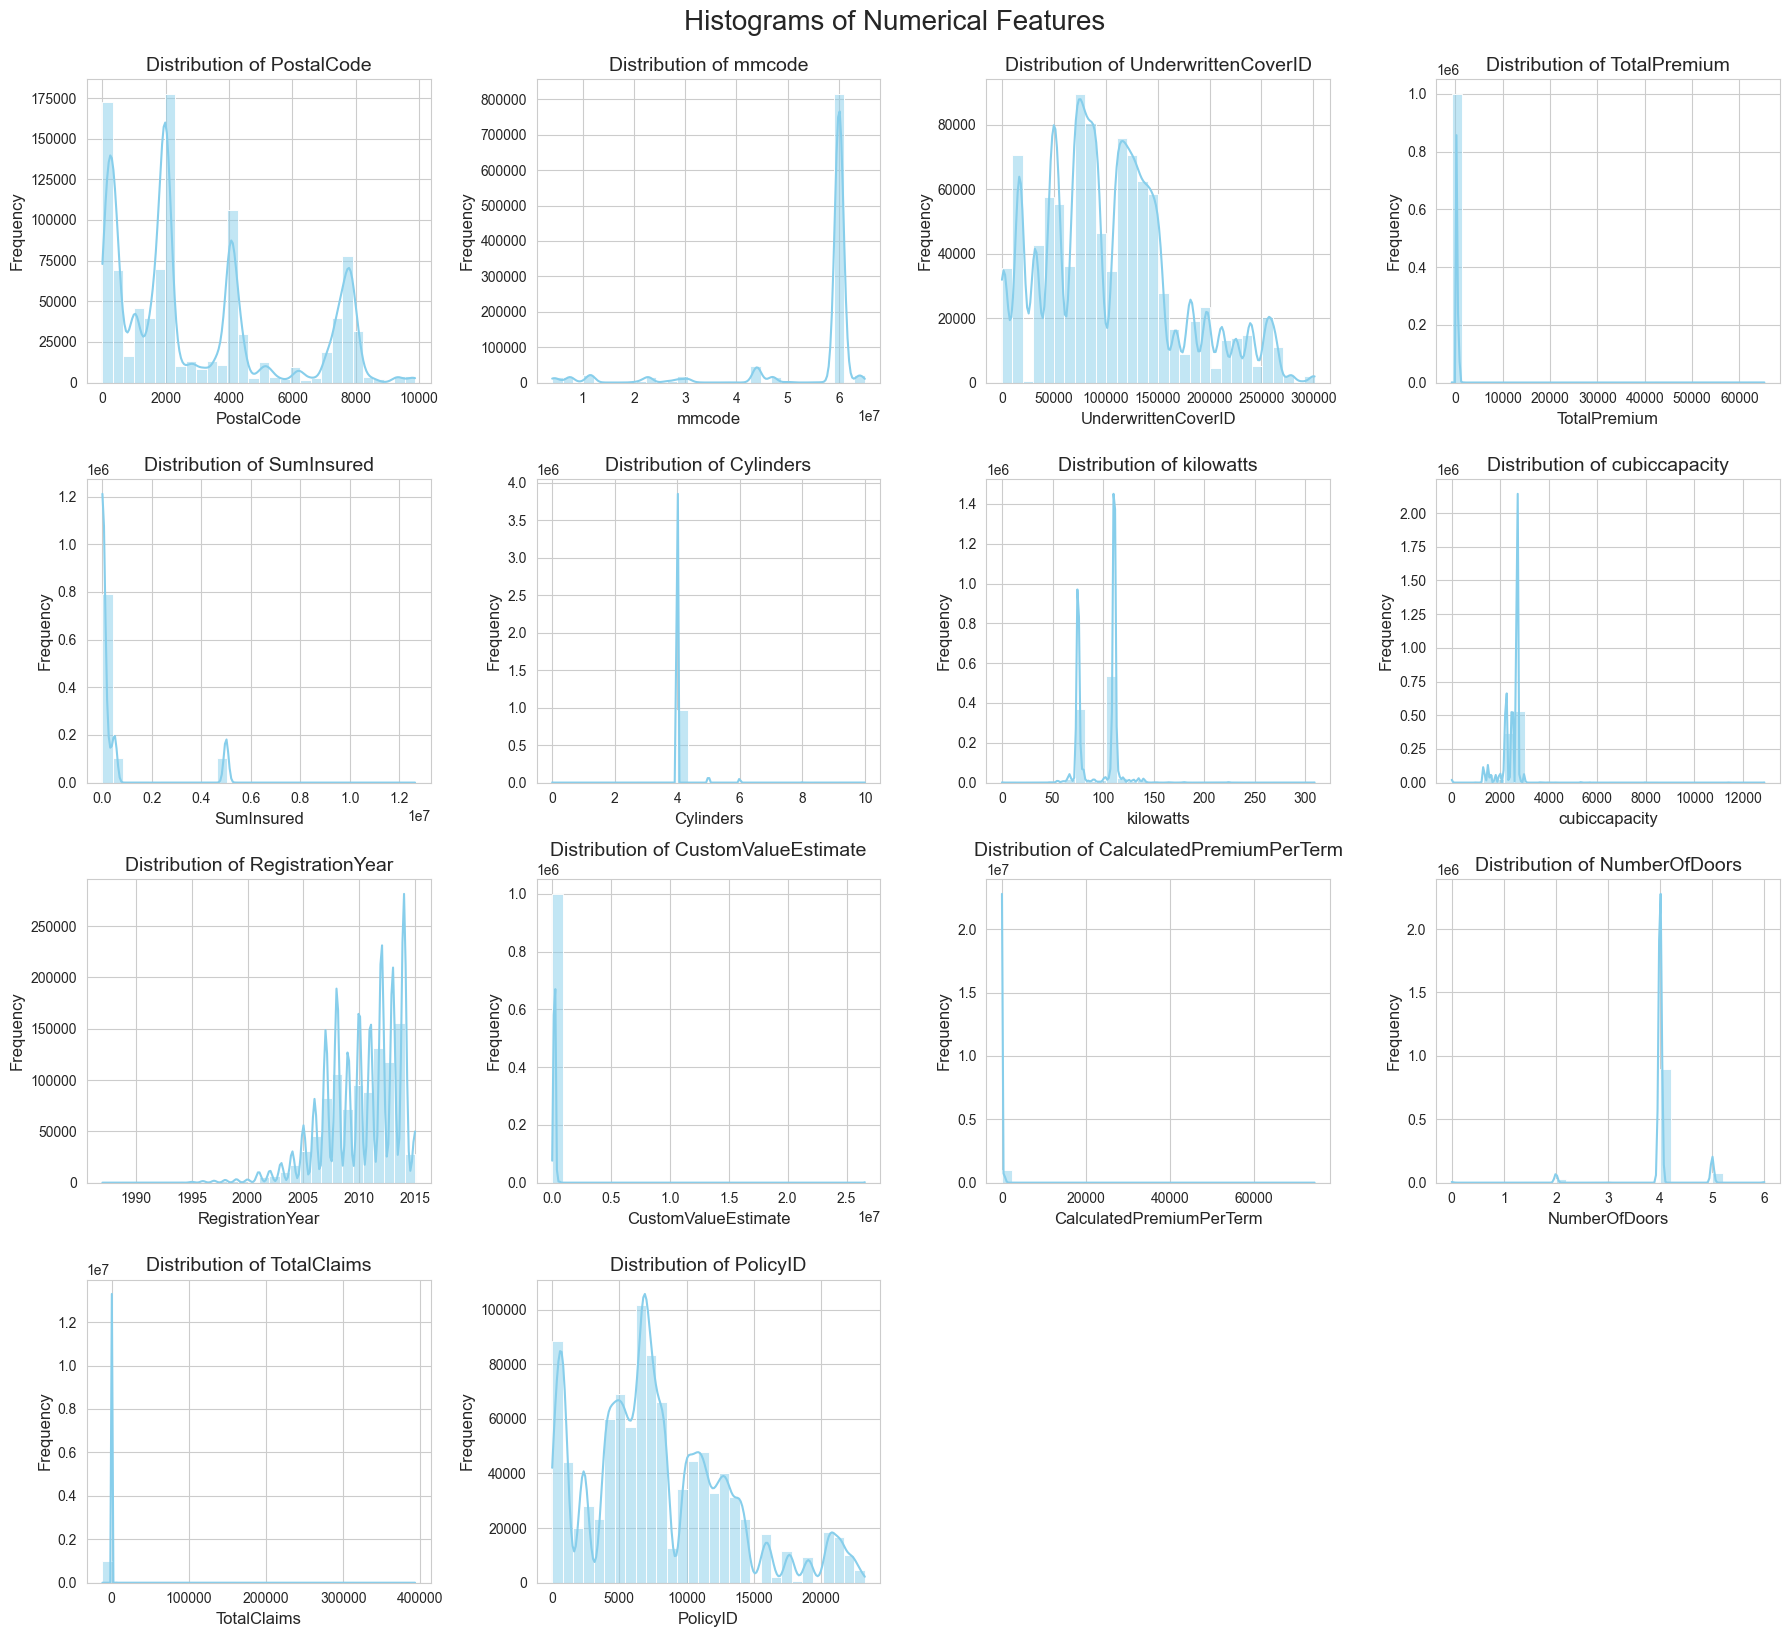


--- Univariate Analysis: Bar Charts for Categorical Columns ---


C:\Users\Fitsum\AppData\Local\Temp\ipykernel_40596\1208222924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
C:\Users\Fitsum\AppData\Local\Temp\ipykernel_40596\1208222924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
C:\Users\Fitsum\AppData\Local\Temp\ipykernel_40596\1208222924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis'

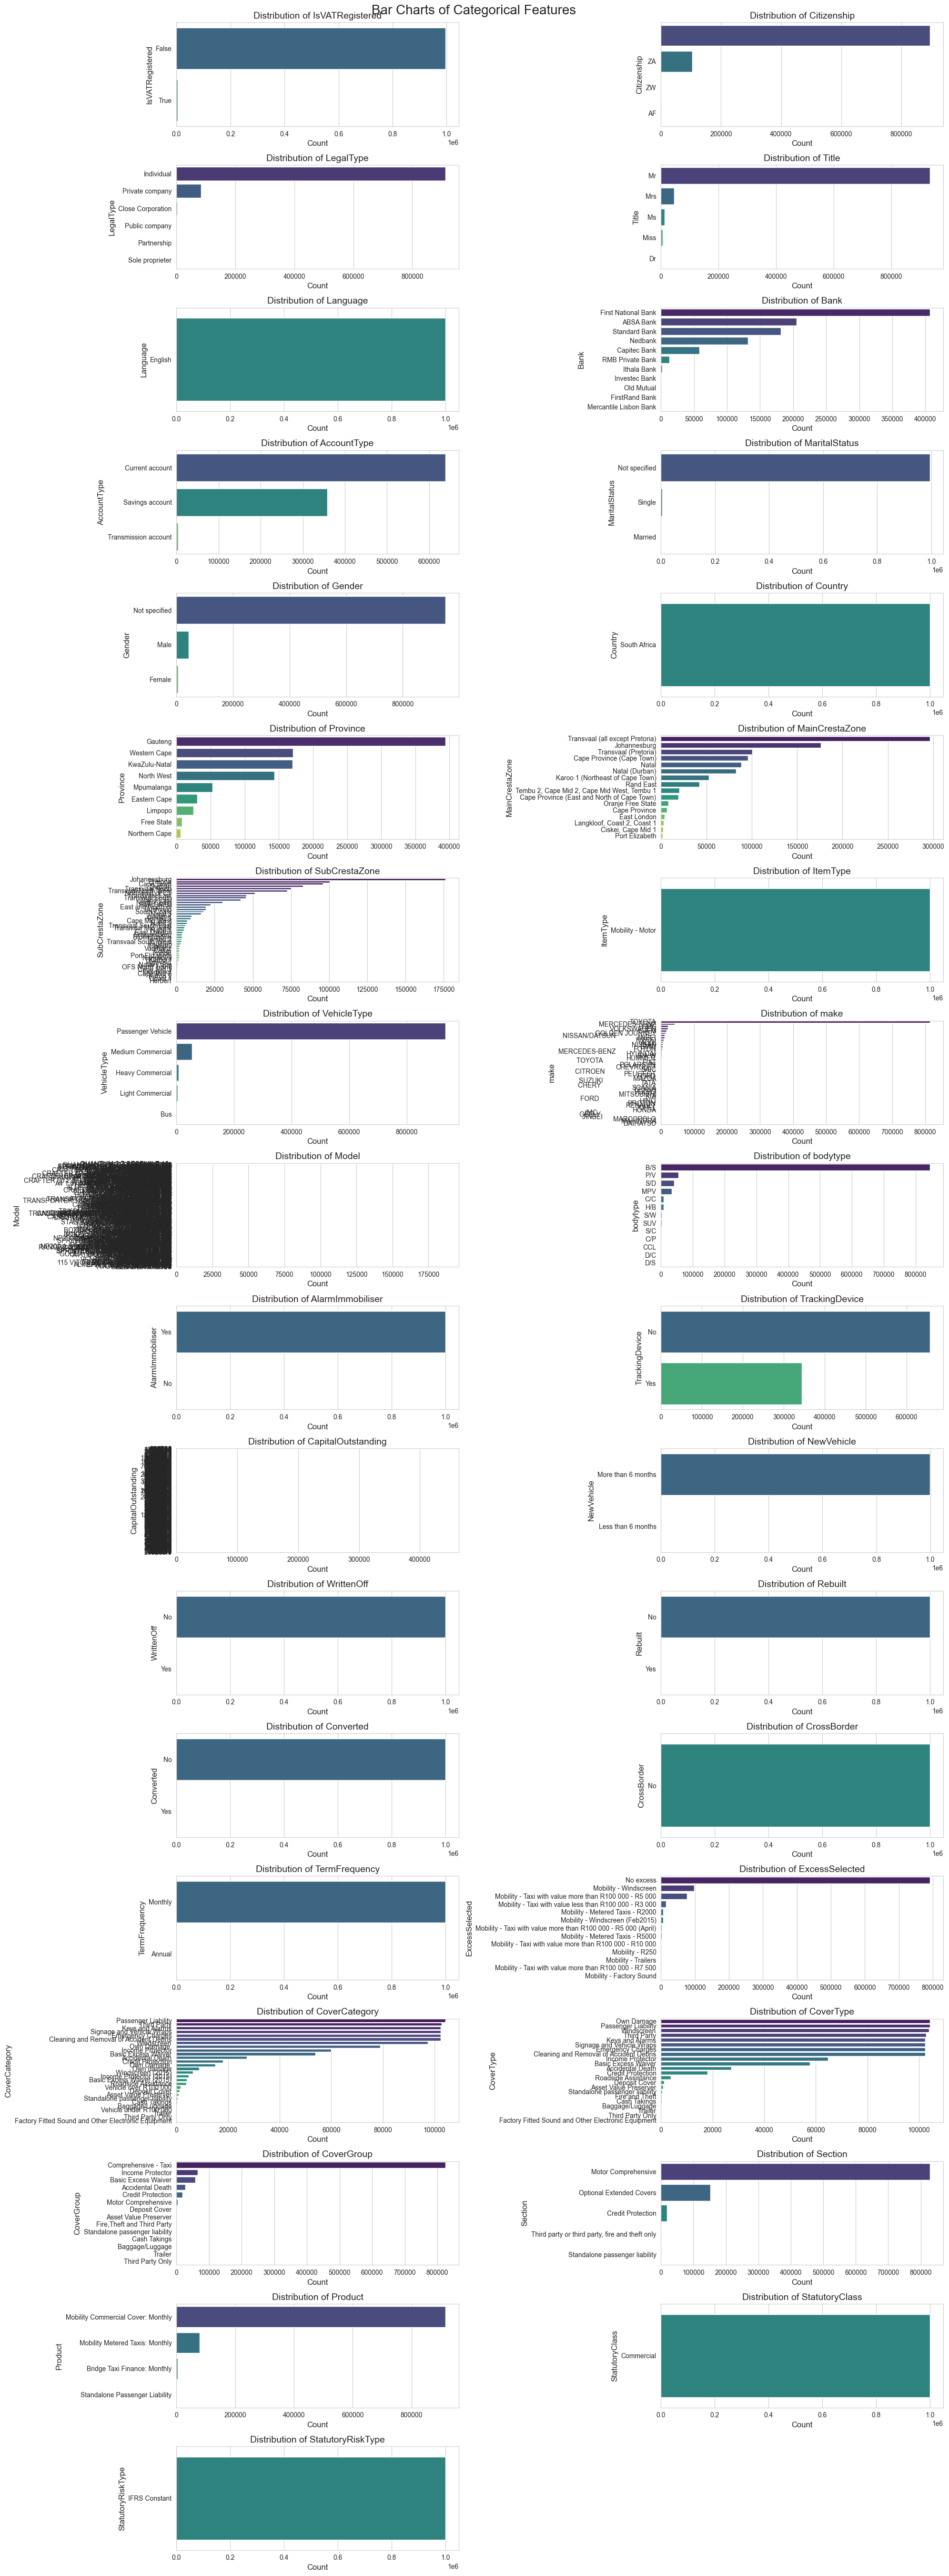

In [12]:
# ---
# ## 4. Univariate Analysis
# ---

# ### 4.1 Distribution of Numerical Variables
# Histograms are plotted to visualize the distribution of numerical columns.
# This helps in understanding the shape of the distribution (e.g., normal, skewed),
# presence of multiple modes, and potential outliers.
print("\n--- Univariate Analysis: Histograms for Numerical Columns ---")
numerical_cols_for_hist = [col for col in key_numerical_features if col in df.columns] # Re-using key_numerical_features
numerical_cols_for_hist.extend(['RegistrationYear', 'NumberOfDoors'])
numerical_cols_for_hist = list(set(numerical_cols_for_hist)) # Remove duplicates

# Filter out columns that might not exist in the actual data 
numerical_cols_for_hist = [col for col in numerical_cols_for_hist if col in df.columns]

plt.figure(figsize=(18, max(4, len(numerical_cols_for_hist)//4 + (len(numerical_cols_for_hist)%4 > 0)) * 4)) # Dynamic figure height
for i, col in enumerate(numerical_cols_for_hist):
    if col in df.columns:
        plt.subplot(len(numerical_cols_for_hist)//4 + (len(numerical_cols_for_hist)%4 > 0), 4, i + 1)
        sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=20)
plt.show()

# ### 4.2 Distribution of Categorical Variables
# Bar charts are used to visualize the frequency distribution of categorical columns.
# This provides insights into the most common categories and the balance across categories.
print("\n--- Univariate Analysis: Bar Charts for Categorical Columns ---")
categorical_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
# Filter out IDs or date columns if they got caught
categorical_cols = [col for col in categorical_cols if 'ID' not in col and 'Date' not in col and 'Month' not in col]

# Filter out columns that might not exist in the actual data
categorical_cols = [col for col in categorical_cols if col in df.columns]

plt.figure(figsize=(20, max(6, len(categorical_cols)//2 + (len(categorical_cols)%2 > 0)) * 3)) # Dynamic figure height
for i, col in enumerate(categorical_cols):
    if col in df.columns:
        plt.subplot(len(categorical_cols)//2 + (len(categorical_cols)%2 > 0), 2, i + 1)
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
plt.tight_layout()
plt.suptitle('Bar Charts of Categorical Features', y=1.00, fontsize=20)
plt.show()

# 


--- Bivariate Analysis: Monthly Premium & Claims by PostalCode Sample ---
   PostalCode     TransactionMonth  MonthlyPremium  MonthlyClaims  NumPolicies
0           1  2013-11-01 00:00:00     1432.740561   50585.078947            2
1           1  2013-12-01 00:00:00     1494.352315       0.000000            2
2           1  2014-01-01 00:00:00     1178.007368       0.000000            2
3           1  2014-02-01 00:00:00     1178.007368       0.000000            2
4           1  2014-03-01 00:00:00     1140.007131       0.000000            2


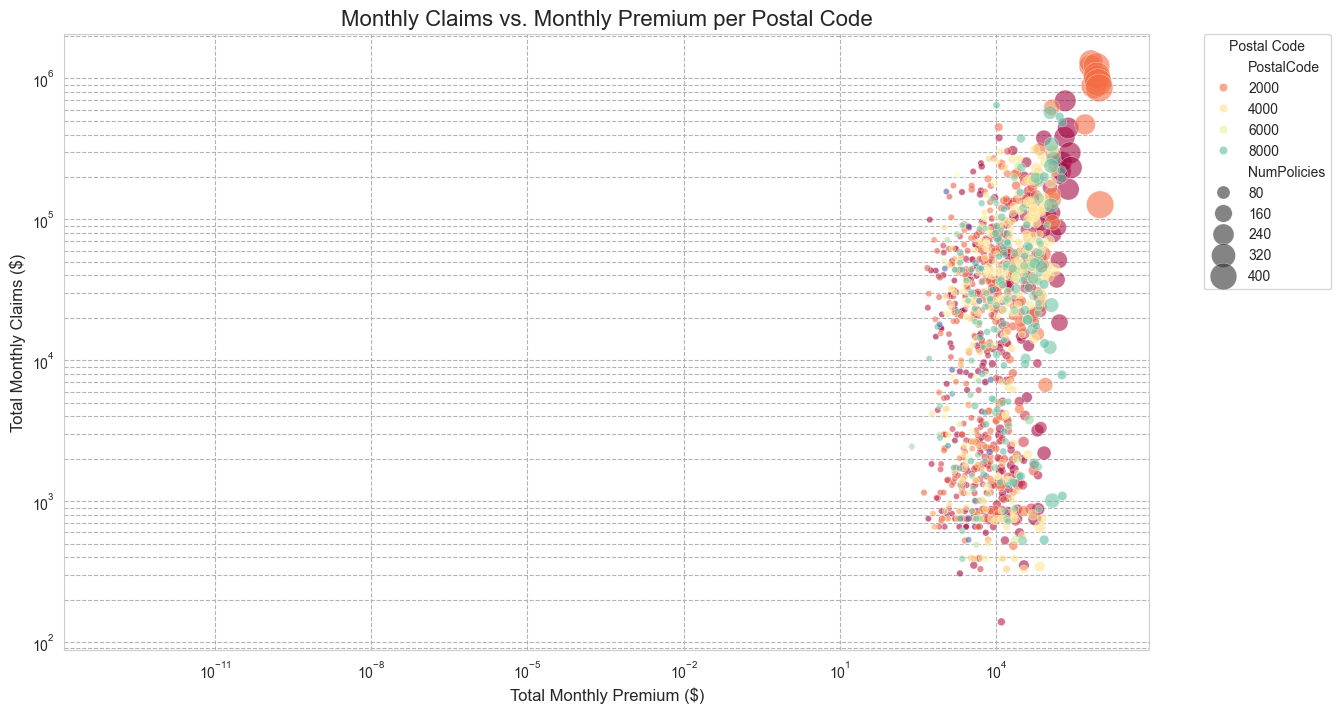


--- Correlation Matrix of Key Numerical Variables ---


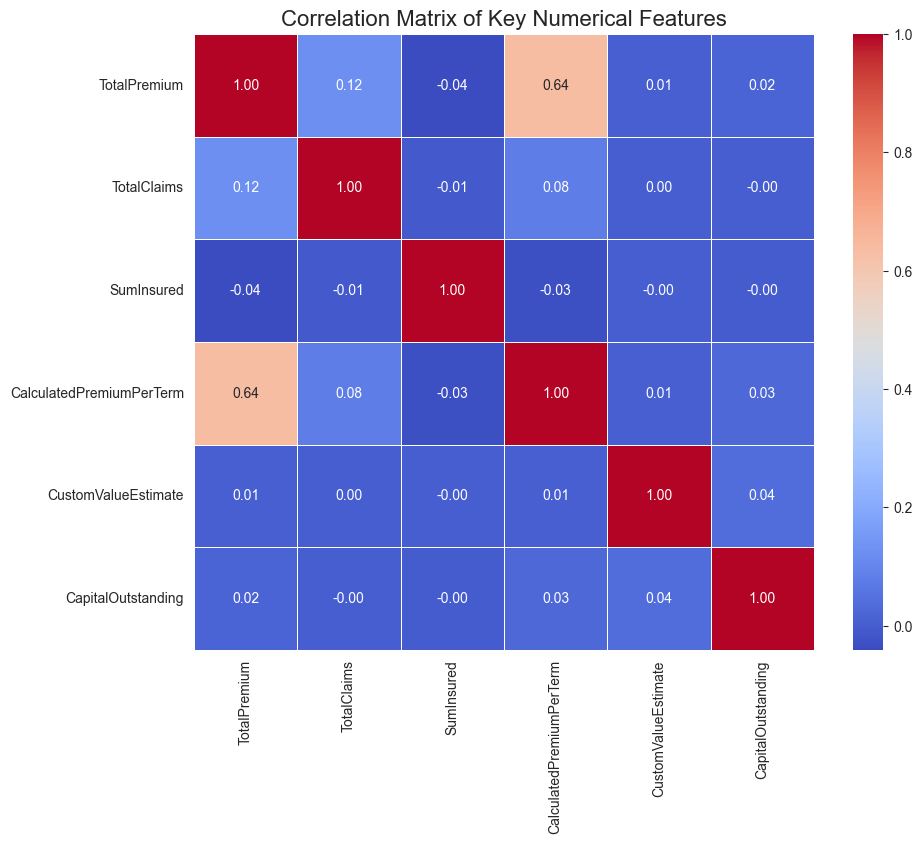

In [16]:
# ---
# ## 5. Bivariate or Multivariate Analysis
# ---

# ### 5.1 Correlations and Associations: TotalPremium vs. TotalClaims by ZipCode
# We will explore the relationship between monthly changes in TotalPremium and TotalClaims
# as a function of ZipCode. First, we need to aggregate the data monthly per PostalCode.

# Ensure TransactionDate is datetime and TransactionMonth is Period
if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['TransactionMonth'] = df['TransactionDate'].dt.to_period('M')
else:
    print("Warning: 'TransactionDate' column not found. Skipping monthly aggregation by PostalCode.")
    # No longer creating an empty DataFrame here, as missing columns will halt execution later.


if not df.empty and 'PostalCode' in df.columns and 'TransactionMonth' in df.columns and 'TotalPremium' in df.columns and 'TotalClaims' in df.columns and 'PolicyID' in df.columns:
    # Aggregate data by PostalCode and TransactionMonth
    monthly_zip_summary = df.groupby(['PostalCode', 'TransactionMonth']).agg(
        MonthlyPremium=('TotalPremium', 'sum'),
        MonthlyClaims=('TotalClaims', 'sum'),
        NumPolicies=('PolicyID', 'nunique')
    ).reset_index()

    # Convert TransactionMonth back to datetime for plotting purposes if needed, or keep as Period
    #monthly_zip_summary['TransactionMonth_dt'] = monthly_zip_summary['TransactionMonth'].dt.to_timestamp()

    print("\n--- Bivariate Analysis: Monthly Premium & Claims by PostalCode Sample ---")
    print(monthly_zip_summary.head())

    # Scatter plot: Monthly Premium vs. Monthly Claims per PostalCode
    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=monthly_zip_summary, x='MonthlyPremium', y='MonthlyClaims', hue='PostalCode',
                    size='NumPolicies', sizes=(20, 400), alpha=0.6, palette='Spectral')
    plt.title('Monthly Claims vs. Monthly Premium per Postal Code', fontsize=16)
    plt.xlabel('Total Monthly Premium ($)')
    plt.ylabel('Total Monthly Claims ($)')
    plt.xscale('log') # Use log scale due to potential large range
    plt.yscale('log')
    plt.legend(title='Postal Code', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.show()
else:
    print("\nSkipping Bivariate Analysis (Monthly Premium & Claims by PostalCode) due to missing required columns (PostalCode, TransactionMonth, TotalPremium, TotalClaims, PolicyID).")


# Correlation Matrix between key numerical variables
print("\n--- Correlation Matrix of Key Numerical Variables ---")
correlation_matrix_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm', 'CustomValueEstimate', 'CapitalOutstanding', 'Kilowatts']
# Filter columns that actually exist in the DataFrame
correlation_matrix_cols = [col for col in correlation_matrix_cols if col in df.columns]

if len(correlation_matrix_cols) > 1: # Need at least two columns to calculate correlation
    # Ensure numerical columns are properly formatted
    for col in correlation_matrix_cols:
        if col in df.columns:
            df[col] = df[col].replace(',', '.', regex=True)  # Replace commas with dots
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, coercing errors to NaN
    
    # Drop rows with NaN values in the correlation matrix columns
    df_cleaned = df[correlation_matrix_cols].dropna()
    
    # Compute correlation matrix
    correlation_df = df_cleaned.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Key Numerical Features', fontsize=16)
    plt.show()
else:
    print("Not enough numerical columns available to compute a correlation matrix.")



C:\Users\Fitsum\AppData\Local\Temp\ipykernel_40596\3674418675.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_premium_province.values, y=avg_premium_province.index, palette='rocket')


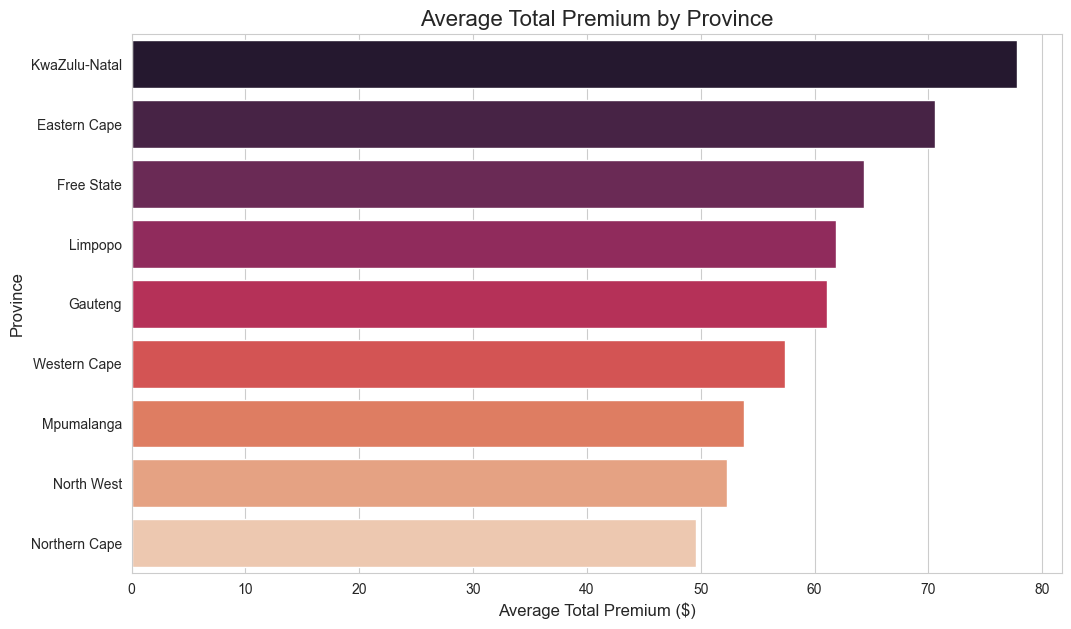


Skipping Top 5 Auto Makes by Province (Count) as 'Province' or 'Make' column is missing.


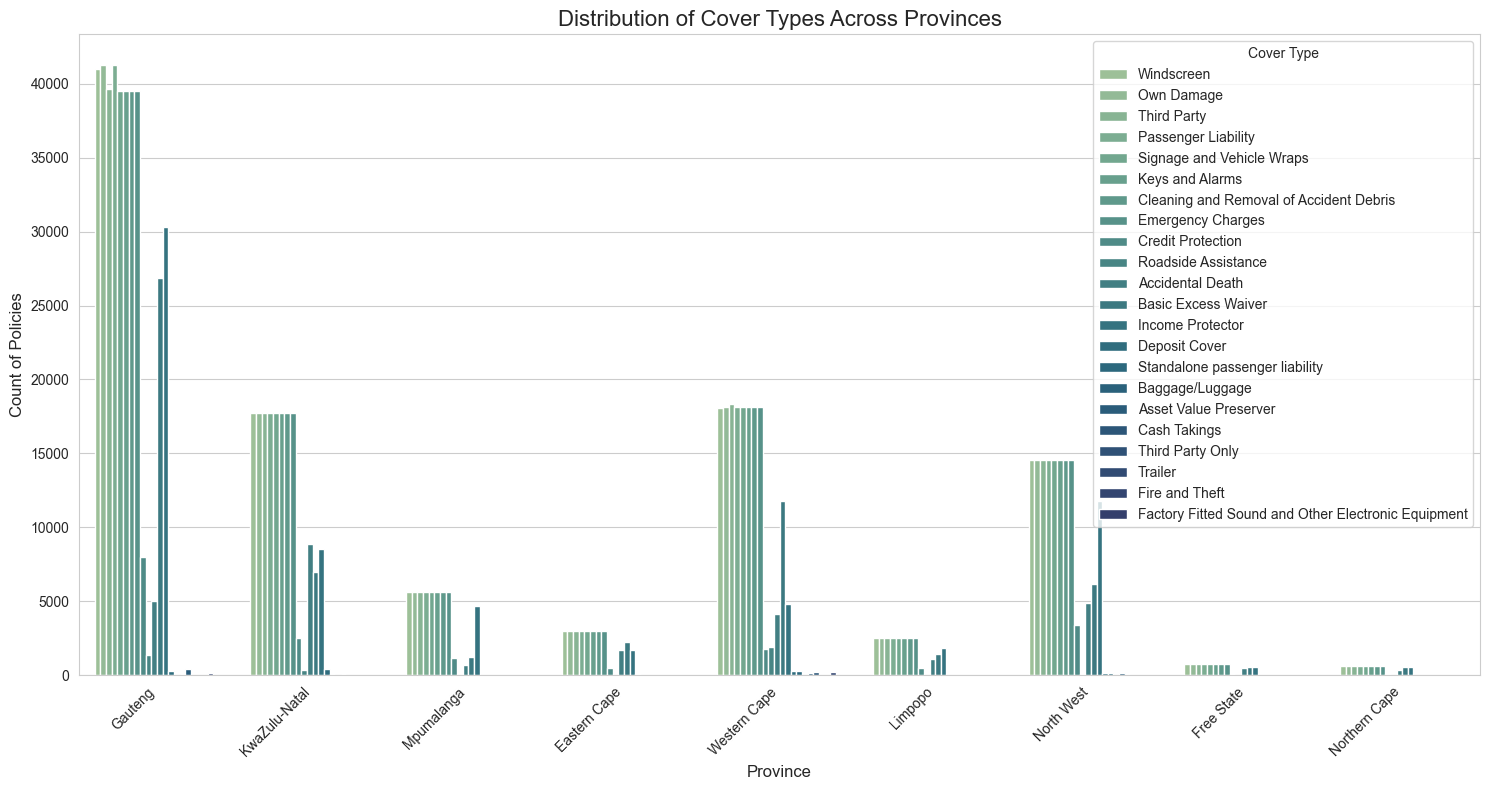

In [17]:

# ---
# ## 6. Data Comparison (Trends Over Geography)
# ---

# Compare the change in insurance cover type, premium, auto make across provinces.

if 'Province' in df.columns and 'TotalPremium' in df.columns:
    # ### 6.1 Average Premium by Province
    plt.figure(figsize=(12, 7))
    avg_premium_province = df.groupby('Province')['TotalPremium'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_premium_province.values, y=avg_premium_province.index, palette='rocket')
    plt.title('Average Total Premium by Province', fontsize=16)
    plt.xlabel('Average Total Premium ($)')
    plt.ylabel('Province')
    plt.show()
else:
    print("\nSkipping Average Premium by Province as 'Province' or 'TotalPremium' column is missing.")


if 'Province' in df.columns and 'Make' in df.columns:
    # ### 6.2 Top 5 Auto Makes by Province (Count)
    print("\n--- Top 5 Auto Makes by Province (Count) ---")
    # Get actual unique provinces from the data, limit to max 5 for plotting clarity
    actual_provinces = df['Province'].value_counts().index.tolist()[:5]

    plt.figure(figsize=(18, 10))
    for i, province in enumerate(actual_provinces):
        plt.subplot(2, 3, i + 1)
        top_makes_province = df[df['Province'] == province]['Make'].value_counts().head(5)
        if not top_makes_province.empty:
            sns.barplot(x=top_makes_province.values, y=top_makes_province.index, palette='cubehelix')
            plt.title(f'Top 5 Auto Makes in {province}', fontsize=14)
            plt.xlabel('Count')
            plt.ylabel('Auto Make')
        else:
            plt.title(f'No Make data for {province}', fontsize=14)
            plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.tight_layout()
    plt.suptitle('Top Auto Makes Across Select Provinces', y=1.02, fontsize=20)
    plt.show()
else:
    print("\nSkipping Top 5 Auto Makes by Province (Count) as 'Province' or 'Make' column is missing.")


if 'Province' in df.columns and 'CoverType' in df.columns:
    # ### 6.3 Distribution of Cover Types by Province
    plt.figure(figsize=(15, 8))
    sns.countplot(data=df, x='Province', hue='CoverType', palette='crest')
    plt.title('Distribution of Cover Types Across Provinces', fontsize=16)
    plt.xlabel('Province')
    plt.ylabel('Count of Policies')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Cover Type')
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping Distribution of Cover Types by Province as 'Province' or 'CoverType' column is missing.")



--- Outlier Detection using Box Plots ---


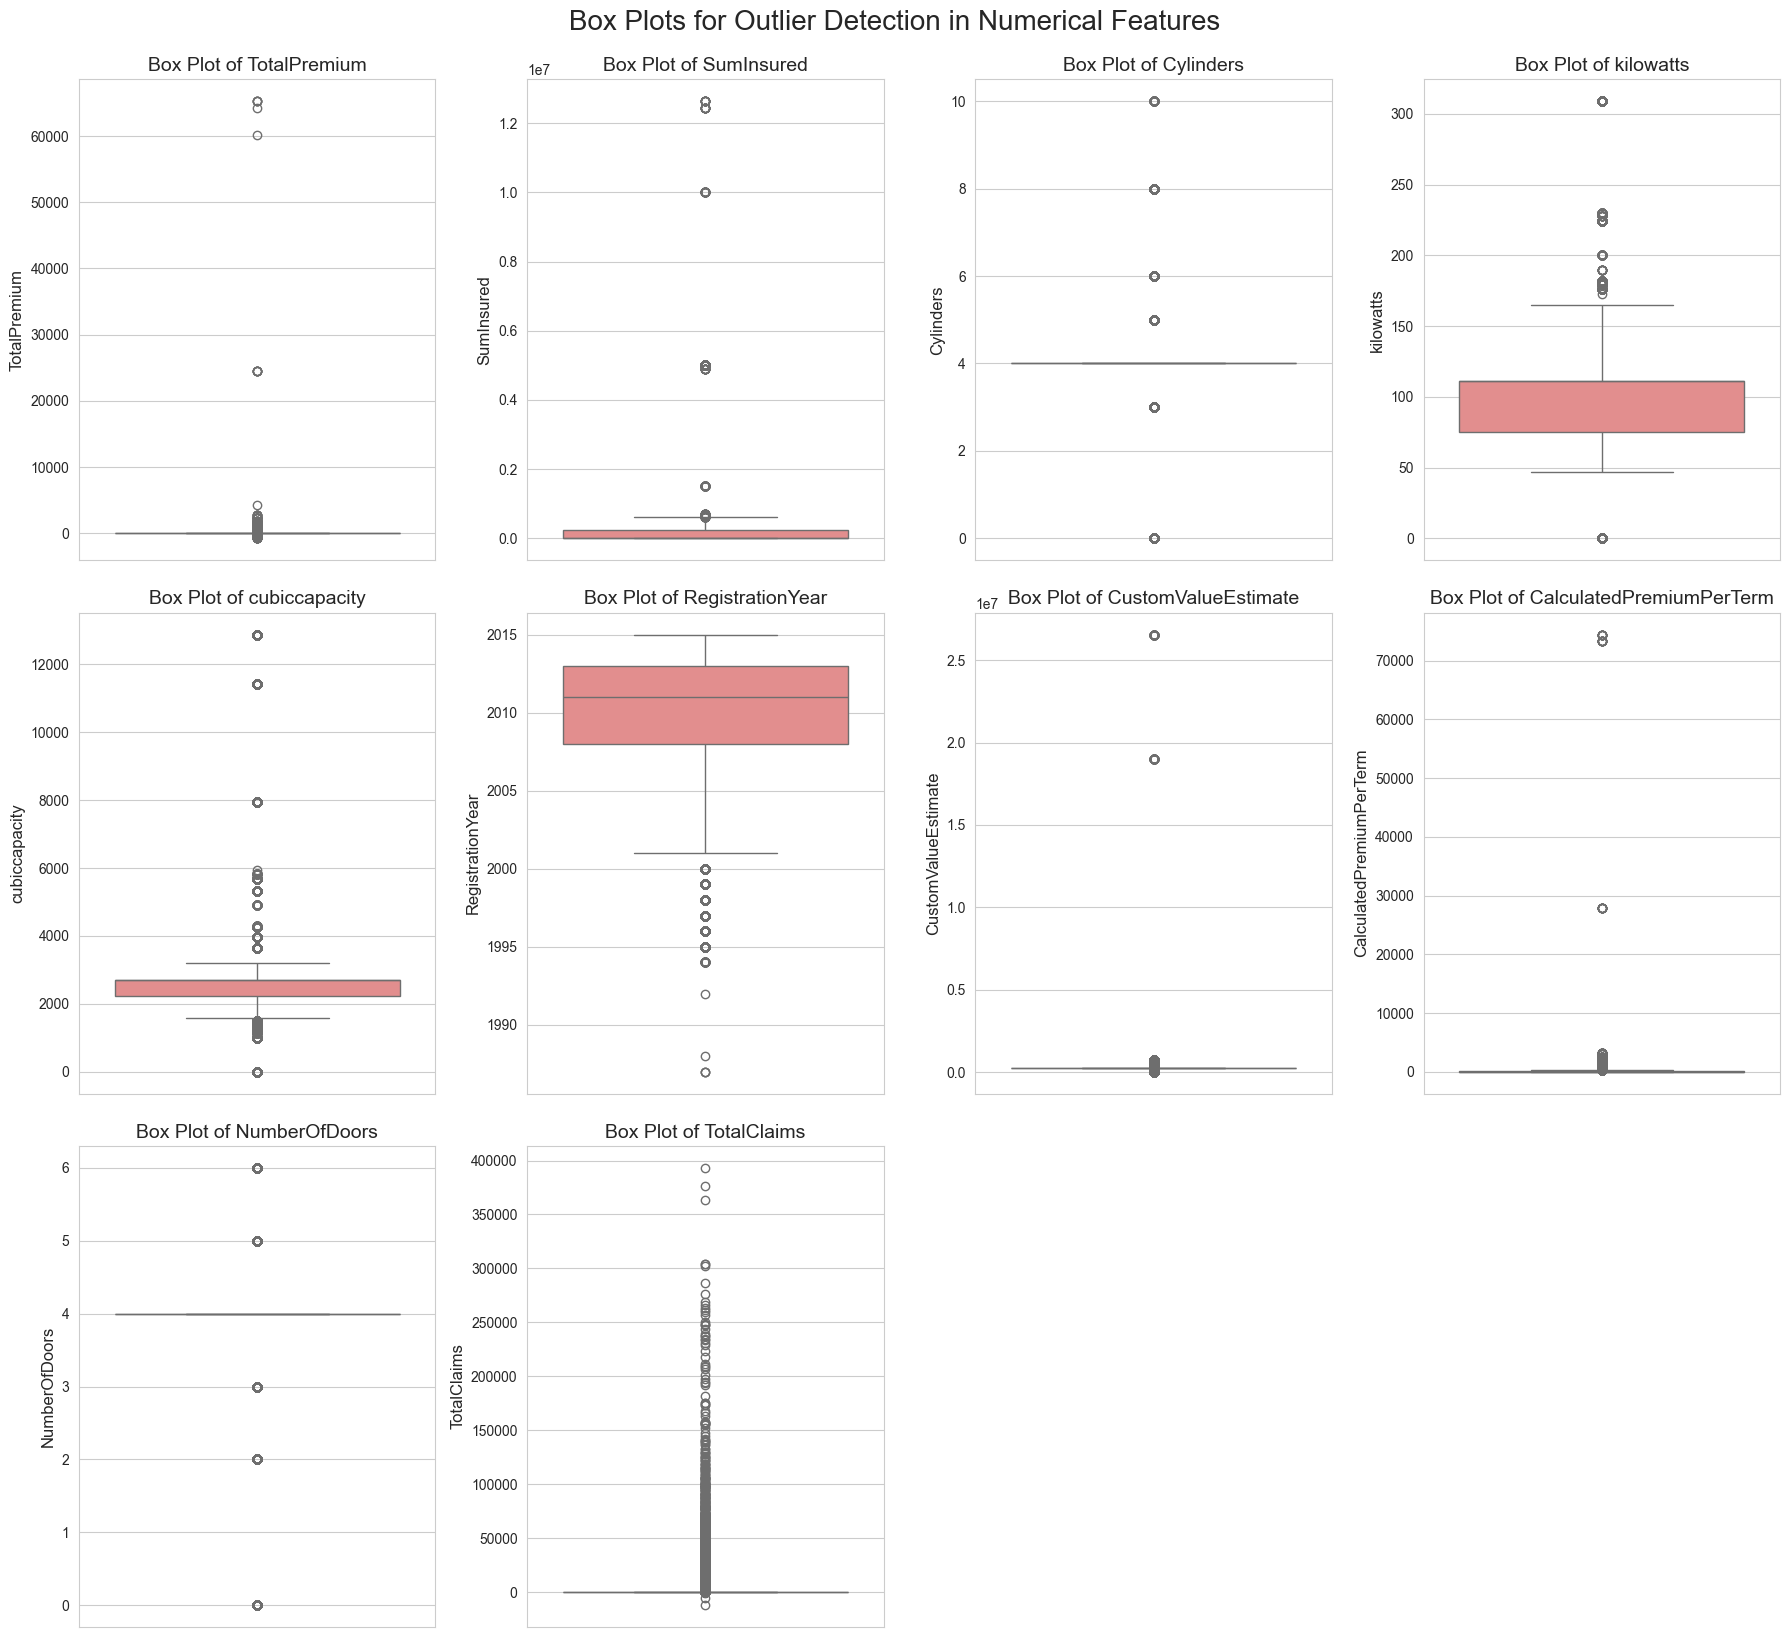

In [19]:
# ---
# ## 7. Outlier Detection
# ---

# Using box plots to detect outliers in numerical data. Outliers are points that fall
# outside 1.5 times the interquartile range (IQR) above the upper quartile or below the lower quartile.

print("\n--- Outlier Detection using Box Plots ---")
# Ensure numerical_cols_for_hist is updated based on actual available columns
numerical_cols_for_hist_actual = [col for col in numerical_cols_for_hist if col in df.columns]
columns_to_exclude = ['UnderwrittenCoverID', 'PolicyID','mmcode','NumberOfVehiclesInFleet','PostalCode']
numerical_cols_for_hist_actual = [col for col in numerical_cols_for_hist_actual if col not in columns_to_exclude]

if numerical_cols_for_hist_actual:
    plt.figure(figsize=(18, max(4, len(numerical_cols_for_hist_actual)//4 + (len(numerical_cols_for_hist_actual)%4 > 0)) * 4))
    for i, col in enumerate(numerical_cols_for_hist_actual):
        plt.subplot(len(numerical_cols_for_hist_actual)//4 + (len(numerical_cols_for_hist_actual)%4 > 0), 4, i + 1)
        sns.boxplot(y=df[col].dropna(), color='lightcoral')
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col)
    plt.tight_layout()
    plt.suptitle('Box Plots for Outlier Detection in Numerical Features', y=1.02, fontsize=20)
    plt.show()
else:
    print("No numerical columns available for outlier detection via box plots.")



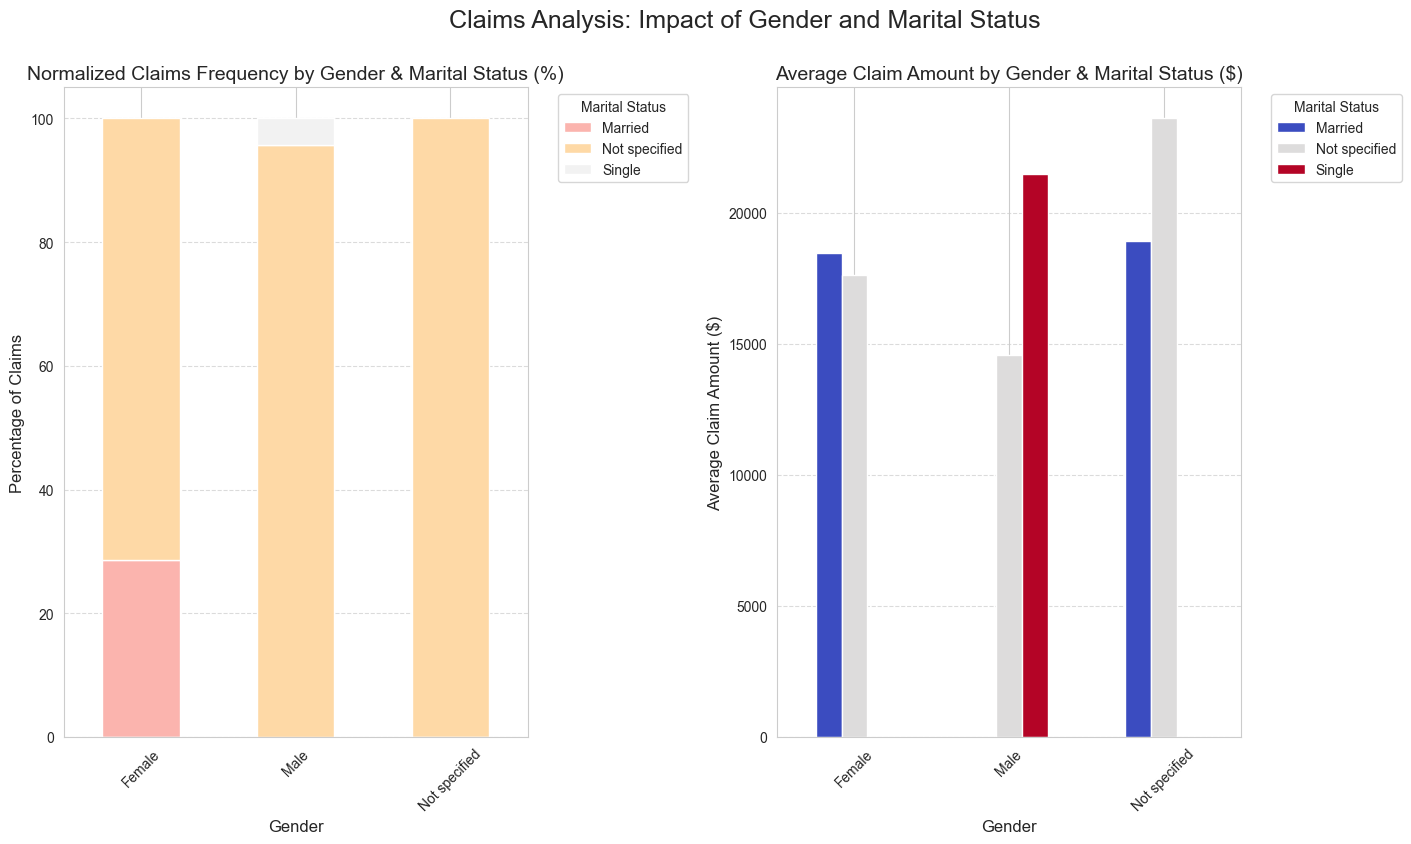

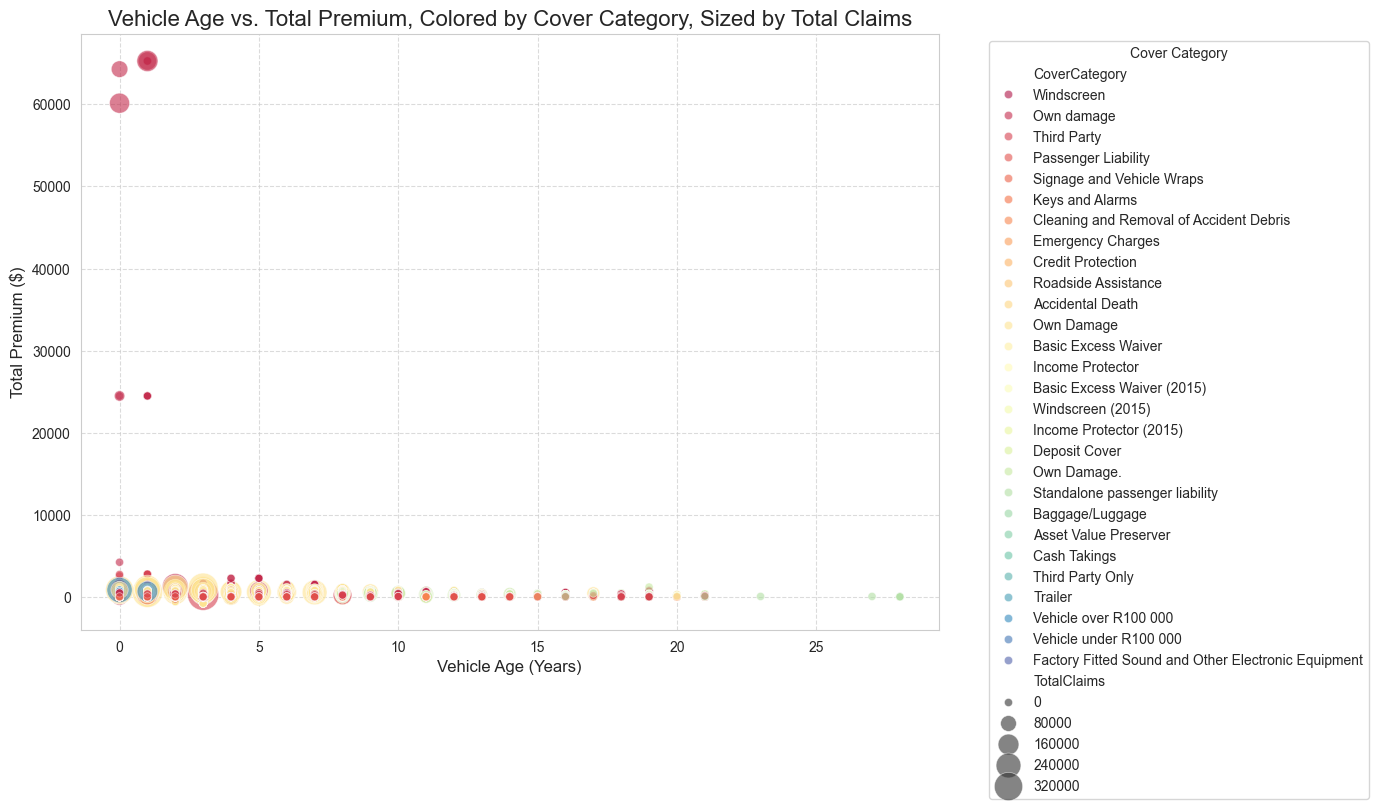

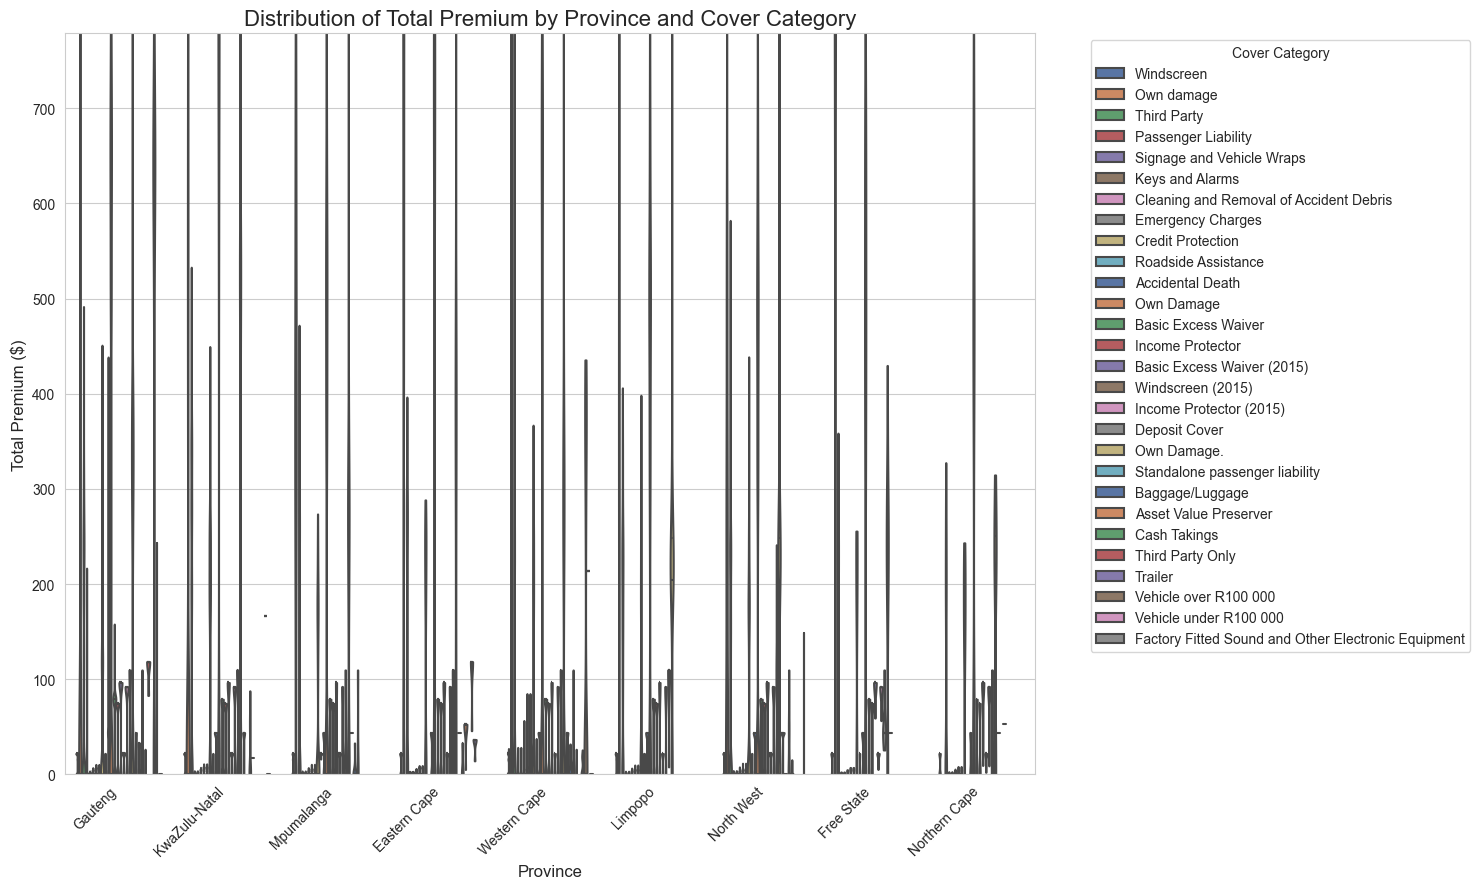

In [22]:
# ---
# ## 8. Creative and Beautiful Plots Capturing Key Insights
# ---

# These plots aim to visualize insights gained from the EDA in an engaging way.

# ### Plot 1: Claims Frequency and Average Claim Amount by Gender & Marital Status
# This plot combines two key client attributes to show how claims behavior differs.
if 'Gender' in df.columns and 'MaritalStatus' in df.columns and 'TotalClaims' in df.columns:
    plt.figure(figsize=(15, 8))

    # Subplot 1: Claims Frequency
    plt.subplot(1, 2, 1)
    # Ensure all required columns are present before proceeding
    if not df[df['TotalClaims'] > 0].empty:
        gender_marital_claims_freq = df[df['TotalClaims'] > 0].groupby(['Gender', 'MaritalStatus']).size().unstack(fill_value=0)
        # Check if sum is not zero to avoid division by zero
        if not gender_marital_claims_freq.empty and gender_marital_claims_freq.sum(axis=1).any():
            gender_marital_claims_freq_norm = gender_marital_claims_freq.div(gender_marital_claims_freq.sum(axis=1), axis=0) * 100 # Normalize
            gender_marital_claims_freq_norm.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='Pastel1')
            plt.title('Normalized Claims Frequency by Gender & Marital Status (%)', fontsize=14)
            plt.xlabel('Gender')
            plt.ylabel('Percentage of Claims')
            plt.xticks(rotation=45)
            plt.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
        else:
            plt.title('No claims data for frequency analysis', fontsize=14)
            plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    else:
        plt.title('No claims data for frequency analysis', fontsize=14)
        plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


    # Subplot 2: Average Claim Amount
    plt.subplot(1, 2, 2)
    if not df[df['TotalClaims'] > 0].empty:
        avg_claims_gender_marital = df[df['TotalClaims'] > 0].groupby(['Gender', 'MaritalStatus'])['TotalClaims'].mean().unstack()
        if not avg_claims_gender_marital.empty:
            avg_claims_gender_marital.plot(kind='bar', ax=plt.gca(), cmap='coolwarm')
            plt.title('Average Claim Amount by Gender & Marital Status ($)', fontsize=14)
            plt.xlabel('Gender')
            plt.ylabel('Average Claim Amount ($)')
            plt.xticks(rotation=45)
            plt.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
        else:
            plt.title('No claims data for average amount analysis', fontsize=14)
            plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    else:
        plt.title('No claims data for average amount analysis', fontsize=14)
        plt.text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.suptitle('Claims Analysis: Impact of Gender and Marital Status', y=1.05, fontsize=18)
    plt.show()
else:
    print("\nSkipping Plot 1 (Claims Analysis) due to missing required columns (Gender, MaritalStatus, TotalClaims).")

# ### Plot 2: Relationship between Vehicle Age, Premium, and Claims
# This plot explores how the age of the vehicle impacts both premium and claims,
# using a scatter plot with size and color encoding.

if 'TransactionMonth' in df.columns and 'RegistrationYear' in df.columns and 'TotalPremium' in df.columns and 'TotalClaims' in df.columns and 'CoverCategory' in df.columns:
    #convert TransactionMonth to datetime if not already
    if not pd.api.types.is_datetime64_any_dtype(df['TransactionMonth']):
        df['TransactionDate'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
    # Calculate vehicle age
    df['VehicleAge'] = df['TransactionDate'].dt.year - df['RegistrationYear']
    df['VehicleAge'] = df['VehicleAge'].apply(lambda x: max(0, x)) # Ensure age is non-negative

    plt.figure(figsize=(14, 8))
    sns.scatterplot(data=df, x='VehicleAge', y='TotalPremium', size='TotalClaims',
                    hue='CoverCategory', sizes=(20, 500), alpha=0.6, palette='Spectral',
                    edgecolor='w', linewidth=0.5)
    plt.title('Vehicle Age vs. Total Premium, Colored by Cover Category, Sized by Total Claims', fontsize=16)
    plt.xlabel('Vehicle Age (Years)')
    plt.ylabel('Total Premium ($)')
    plt.legend(title='Cover Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping Plot 2 (Vehicle Age, Premium, and Claims) due to missing required columns (TransactionDate, RegistrationYear, TotalPremium, TotalClaims, CoverCategory).")


# ### Plot 3: Premium Distribution by Province and Cover Category
# A violin plot to show the distribution of TotalPremium across provinces,
# further split by Cover Category to highlight variations.

if 'Province' in df.columns and 'TotalPremium' in df.columns and 'CoverCategory' in df.columns:
    plt.figure(figsize=(15, 9))
    sns.violinplot(data=df, x='Province', y='TotalPremium', hue='CoverCategory',
                   inner='quartile', palette='deep', linewidth=1.5, cut=0)
    plt.title('Distribution of Total Premium by Province and Cover Category', fontsize=16)
    plt.xlabel('Province')
    plt.ylabel('Total Premium ($)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df['TotalPremium'].quantile(0.99)) # Clip outliers for better visualization
    plt.legend(title='Cover Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping Plot 3 (Premium Distribution by Province and Cover Category) due to missing required columns (Province, TotalPremium, CoverCategory).")


# ---
# ## Conclusion of EDA
# ---
# This Exploratory Data Analysis has provided initial insights into the AlphaCare insurance dataset.
# We've examined data structure, quality, and distributions of key variables.
#
# **Key Observations:**
# - Data types were mostly appropriate, with date columns handled.
# - Missing values were addressed using simple imputation strategies (median for numerical, mode for categorical).
# - Distributions of financial metrics like `TotalPremium` and `TotalClaims` are highly skewed, indicating a need for potential transformations (e.g., log transformation) for modeling.
# - There are clear variations in average premiums and claims across provinces, and different preferences for auto makes and cover types.
# - Outliers are present in many numerical features, which will require careful consideration during model building.
# - Relationships between vehicle age, premium, and claims, and the impact of demographic factors like gender and marital status on claims behavior, have been highlighted through visualizations.
#
# These insights will be crucial for guiding the A/B hypothesis testing and machine learning model development phases of the project